In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
from src.preprocessing import *

In [2]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")

In [3]:
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Property_Area,Age,Loan_Status,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,Purpose_of_Loan,Existing_EMIs,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Business_Type,Asset_Value,Guarantor,Co-signer_Relationship,Monthly_Expense,Organization_Type,Region_Branch,Mobile_Verified,Email_Verified,Institutional_Relationships,Application_Text,Customer_Feedback,Agent_Notes,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,8031545,360,1,Urban,36,Approved,699,683712,0.098,Home,5610,0,0,1,NaN,744861,No,Friend,30391,Public,KOL-004,No,Yes,"RBI:Regulatory, NPCI:Payments integration, CIB...",Applicant requests home loan for amount INR 80...,Neutral — application was okay; expects quicke...,Verified documents; requires guarantor for app...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,899361,240,1,Rural,42,Rejected,707,22272,4.939,Business,9166,1,0,0,NaN,0,No,Sibling,1856,Startup,DEL-001,No,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant requests business loan for amount IN...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,2387748,60,1,Rural,38,Approved,641,774636,0.000,Business,0,2,0,1,NaN,2913766,No,NaN,24557,Private,BLR-003,Yes,Yes,"CIBIL:Credit checks, NPCI:Payments, GSTN:Tax l...",Applicant requests business loan for amount IN...,"Satisfied with application process, but unhapp...",Escalated to relationship manager for manual C...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,658856,12,1,Semiurban,32,Approved,677,1061400,0.301,Personal,26613,1,0,3,NaN,3488244,No,Friend,36750,Startup,KOL-004,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,198671,36,0,Semiurban,35,Approved,594,114468,0.000,Personal,0,0,0,2,Agriculture,472179,No,Parent,3920,Public,BLR-003,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Appreciative of online service and prompt comm...,Verified documents; requires guarantor for app...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [4]:
df.tail()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Property_Area,Age,Loan_Status,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,Purpose_of_Loan,Existing_EMIs,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Business_Type,Asset_Value,Guarantor,Co-signer_Relationship,Monthly_Expense,Organization_Type,Region_Branch,Mobile_Verified,Email_Verified,Institutional_Relationships,Application_Text,Customer_Feedback,Agent_Notes,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
995,HDFC100996,HDFC Bank,Simran Kaur,Male,Yes,1,Graduate,Salaried,44713,0,5883603,360,1,Urban,35,Approved,707,536556,0.116,Home,5165,1,0,2,NaN,1895538,Yes,Sibling,11899,MNC,HYD-005,Yes,Yes,"CIBIL:Credit checks, NPCI:Payments, GSTN:Tax l...",Applicant mentions dispute with property valua...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,10.965,Neutral,Sikh,Tamil Nadu,Coimbatore,6635,3.830000e+11,9350952889,simran.kaur@example.in,Medical Representative
996,HDFC100997,HDFC Bank,Krishna Mehta,Male,No,2,Graduate,Salaried,70886,0,2780228,300,0,Semiurban,37,Rejected,561,850632,0.284,Home,20102,1,0,1,NaN,2413969,No,Spouse,32458,MNC,KOL-004,Yes,No,"RBI:Regulatory oversight, SEBI:Market insights...",Applicant mentions dispute with property valua...,"Satisfied with application process, but unhapp...",Verified documents; requires guarantor for app...,3.268,Negative,Hindu,Kerala,Trivandrum,217843,7.040000e+11,9176504718,krishna.mehta@example.in,Customer Support Executive
997,HDFC100998,HDFC Bank,Rohan Verma,Female,No,1,Graduate,Salaried,24392,11337,301249,24,1,Semiurban,28,Approved,725,428748,0.966,Education,34514,2,0,0,NaN,1631635,No,Friend,22977,Startup,PUNE-006,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Very dissatisfied — long waits and inconsisten...,High risk — further KYC needed and background ...,0.703,Positive,Hindu,Delhi,New Delhi,89211,9.954289e+10,9966866798,rohan.verma@example.in,Driver
998,HDFC100999,HDFC Bank,Ananya Joshi,Female,No,2,Graduate,Salaried,64803,94136,719891,48,1,Urban,33,Approved,679,1907268,0.214,Auto,34000,1,0,4,NaN,5000832,No,Parent,72376,Private,BLR-003,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Complained about credit score errors and wants...,Verified documents; requires guarantor for app...,0.377,Negative,Hindu,Gujarat,Ahmedabad,532976,6.170000e+11,9103847156,ananya.joshi@example.in,Electrician
999,HDFC101000,HDFC Bank,Saanvi Reddy,Female,Yes,0,Graduate,Self-Employed,22938,0,61019,120,1,Rural,24,Approved,690,275256,0.664,Business,15226,0,0,0,Agriculture,0,Yes,Sibling,16105,Government,BLR-003,Yes,Yes,"CIBIL:Credit checks, NPCI:Payments, GSTN:Tax l...",Applicant cites medical emergency and requests...,"Satisfied with application process, but unhapp...",Verified documents; requires guarantor for app...,0.222,Neutral,Hindu,Uttar Pradesh,Noida,509612,6.510000e+11,9449234359,saanvi.reddy@example.in,Marketing Executive


In [5]:
df.shape

(1000, 47)

In [6]:
df.columns

Index(['Loan_ID', 'Bank', 'Customer_Name', 'Gender', 'Married', 'Dependents',
       'Education', 'Employment_Status', 'Applicant_Income',
       'Coapplicant_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_History', 'Property_Area', 'Age', 'Loan_Status', 'CIBIL_Score',
       'Annual_Household_Income', 'Debt_to_Income_Ratio', 'Purpose_of_Loan',
       'Existing_EMIs', 'Number_of_Previous_Loans', 'Default_History_Count',
       'Employment_Length_Years', 'Business_Type', 'Asset_Value', 'Guarantor',
       'Co-signer_Relationship', 'Monthly_Expense', 'Organization_Type',
       'Region_Branch', 'Mobile_Verified', 'Email_Verified',
       'Institutional_Relationships', 'Application_Text', 'Customer_Feedback',
       'Agent_Notes', 'Loan_to_Annual_Income', 'Customer_Sentiment',
       'Religion', 'State', 'City', 'PIN_Code', 'Aadhaar_Synthetic',
       'Phone_Number', 'Email', 'Occupation'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   object 
 1   Bank                         1000 non-null   object 
 2   Customer_Name                1000 non-null   object 
 3   Gender                       1000 non-null   object 
 4   Married                      1000 non-null   object 
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   object 
 7   Employment_Status            1000 non-null   object 
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

In [8]:
df.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Age,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,Existing_EMIs,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Asset_Value,Monthly_Expense,Loan_to_Annual_Income,PIN_Code,Aadhaar_Synthetic,Phone_Number
count,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1.000000e+03,1.000000e+03
mean,0.849000,42430.057000,9727.11400,2.216713e+06,159.132000,0.72300,34.412000,653.01300,6.258861e+05,148.118157,18173.390000,0.865000,0.147000,2.434000,1.908042e+06,23603.427000,10.163103,509976.40800,4.853217e+11,9.500193e+09
std,0.964951,28133.210769,20568.25945,2.635021e+06,127.056704,0.44774,8.572616,73.83654,4.724545e+05,1974.599103,16298.460525,0.911925,0.499641,2.791673,1.481451e+06,18054.598235,25.415631,289145.26265,2.925311e+11,2.875105e+08
min,0.000000,0.000000,0.00000,1.884000e+03,12.000000,0.00000,18.000000,384.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.003000,622.00000,2.589553e+08,9.002443e+09
25%,0.000000,18260.000000,0.00000,3.729465e+05,36.000000,0.00000,28.000000,605.75000,2.639520e+05,0.031000,1741.750000,0.000000,0.000000,0.000000,7.424400e+05,9159.250000,0.645750,263067.50000,2.190000e+11,9.254018e+09
50%,1.000000,40675.500000,0.00000,9.720460e+05,120.000000,1.00000,35.000000,654.00000,5.512440e+05,0.332000,16289.500000,1.000000,0.000000,2.000000,1.634312e+06,20787.500000,2.309000,517643.50000,4.735000e+11,9.498140e+09
75%,2.000000,61037.250000,7956.50000,3.315038e+06,300.000000,1.00000,40.000000,704.00000,8.565480e+05,0.795000,29718.500000,1.000000,0.000000,3.000000,2.726302e+06,33067.750000,8.326750,756922.00000,7.300000e+11,9.750462e+09
max,3.000000,149266.000000,123461.00000,1.379096e+07,360.000000,1.00000,66.000000,878.00000,2.555340e+06,38342.000000,82436.000000,5.000000,3.000000,15.000000,7.742001e+06,97762.000000,269.754000,998910.00000,9.990000e+11,9.999102e+09


In [10]:
missing_value_summary(df)

,Missing Values,Percentage
Business_Type,799,79.9
Co-signer_Relationship,234,23.4


In [12]:
df.duplicated().sum()

np.int64(0)

In [11]:
basic_cleaning(df)

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Property_Area,Age,Loan_Status,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,Purpose_of_Loan,Existing_EMIs,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Business_Type,Asset_Value,Guarantor,Co-signer_Relationship,Monthly_Expense,Organization_Type,Region_Branch,Mobile_Verified,Email_Verified,Institutional_Relationships,Application_Text,Customer_Feedback,Agent_Notes,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,8031545,360,1,Urban,36,Approved,699,683712,0.098,Home,5610,0,0,1,NaN,744861,No,Friend,30391,Public,KOL-004,No,Yes,"RBI:Regulatory, NPCI:Payments integration, CIB...",Applicant requests home loan for amount INR 80...,Neutral — application was okay; expects quicke...,Verified documents; requires guarantor for app...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,899361,240,1,Rural,42,Rejected,707,22272,4.939,Business,9166,1,0,0,NaN,0,No,Sibling,1856,Startup,DEL-001,No,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant requests business loan for amount IN...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,2387748,60,1,Rural,38,Approved,641,774636,0.000,Business,0,2,0,1,NaN,2913766,No,NaN,24557,Private,BLR-003,Yes,Yes,"CIBIL:Credit checks, NPCI:Payments, GSTN:Tax l...",Applicant requests business loan for amount IN...,"Satisfied with application process, but unhapp...",Escalated to relationship manager for manual C...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,658856,12,1,Semiurban,32,Approved,677,1061400,0.301,Personal,26613,1,0,3,NaN,3488244,No,Friend,36750,Startup,KOL-004,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,198671,36,0,Semiurban,35,Approved,594,114468,0.000,Personal,0,0,0,2,Agriculture,472179,No,Parent,3920,Public,BLR-003,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Appreciative of online service and prompt comm...,Verified documents; requires guarantor for app...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,HDFC100996,HDFC Bank,Simran Kaur,Male,Yes,1,Graduate,Salaried,44713,0,5883603,360,1,Urban,35,Approved,707,536556,0.116,Home,5165,1,0,2,NaN,1895538,Yes,Sibling,11899,MNC,HYD-005,Yes,Yes,"CIBIL:Credit checks, NPCI:Payments, GSTN:Tax l...",Applicant mentions dispute with property valua...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,10.965,Neutral,Sikh,Tamil Nadu,Coimbatore,6635,3.830000e+11,9350952889,simran.kaur@example.in,Medical Representative
996,HDFC100997,HDFC Bank,Krishna Mehta,Male,No,2,Graduate,Salaried,70886,0,2780228,300,0,Semiurban,37,Rejecte

In [14]:
num_cols, cat_cols = get_feature_types(df)

In [15]:
num_cols

['Dependents',
 'Applicant_Income',
 'Coapplicant_Income',
 'Loan_Amount',
 'Loan_Term_Months',
 'Credit_History',
 'Age',
 'CIBIL_Score',
 'Annual_Household_Income',
 'Debt_to_Income_Ratio',
 'Existing_EMIs',
 'Number_of_Previous_Loans',
 'Default_History_Count',
 'Employment_Length_Years',
 'Asset_Value',
 'Monthly_Expense',
 'Loan_to_Annual_Income',
 'PIN_Code',
 'Aadhaar_Synthetic',
 'Phone_Number']

In [16]:
cat_cols

['Loan_ID',
 'Bank',
 'Customer_Name',
 'Gender',
 'Married',
 'Education',
 'Employment_Status',
 'Property_Area',
 'Loan_Status',
 'Purpose_of_Loan',
 'Business_Type',
 'Guarantor',
 'Co-signer_Relationship',
 'Organization_Type',
 'Region_Branch',
 'Mobile_Verified',
 'Email_Verified',
 'Institutional_Relationships',
 'Application_Text',
 'Customer_Feedback',
 'Agent_Notes',
 'Customer_Sentiment',
 'Religion',
 'State',
 'City',
 'Email',
 'Occupation']

In [17]:
"Number of Numerical Columns :", len(num_cols)

('Number of Numerical Columns :', 20)

In [18]:
"Number of Categorical Columns :", len(cat_cols)

('Number of Categorical Columns :', 27)

In [19]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

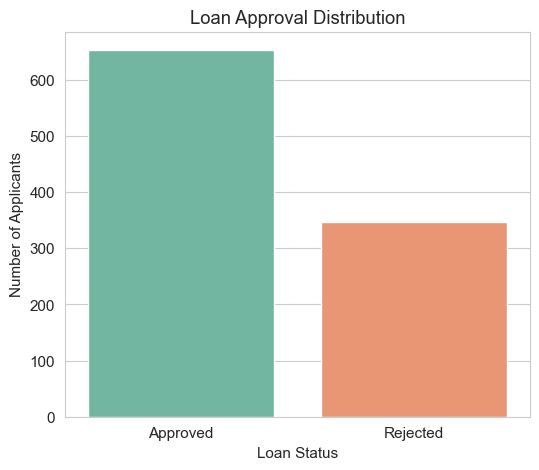

In [20]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x="Loan_Status",
    palette="Set2"
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.savefig("../visuals/loan_status_distribution.png", dpi=300)
plt.show()

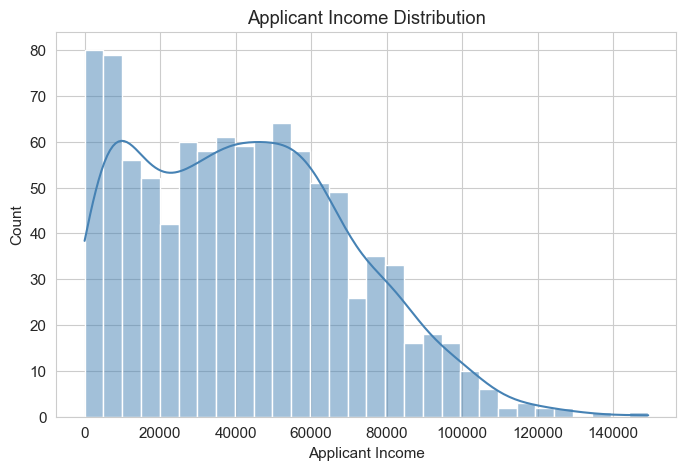

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Applicant_Income"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.savefig("../visuals/income_distribution.png", dpi=300)
plt.show()

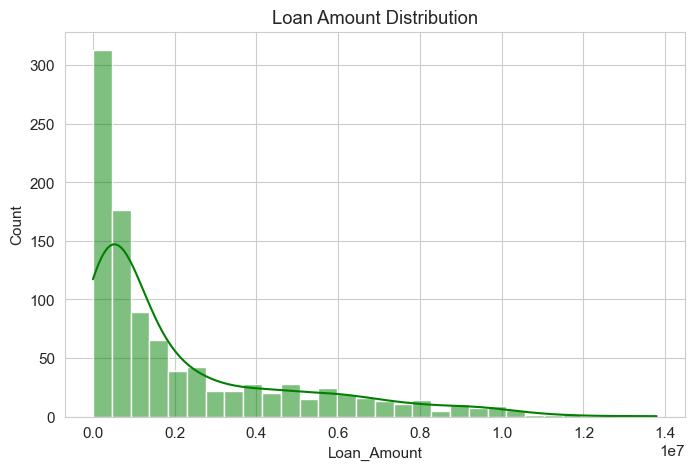

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Loan_Amount"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Loan Amount Distribution")
plt.savefig("../visuals/loan_amount_distribution.png", dpi=300)
plt.show()

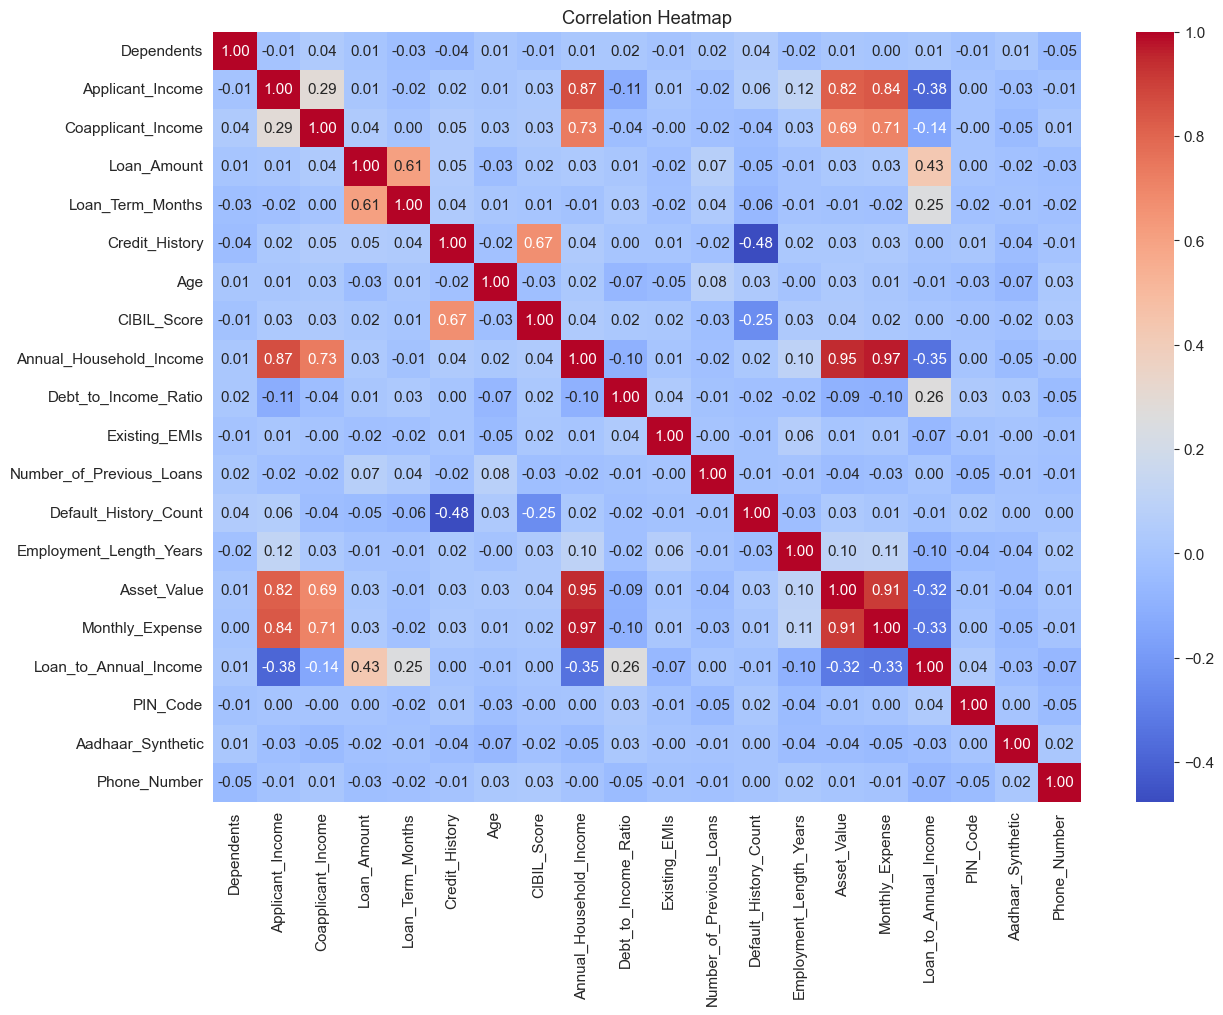

In [23]:
plt.figure(figsize=(14,10))

correlation = df[num_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("../visuals/correlation_heatmap.png", dpi=300)
plt.show()

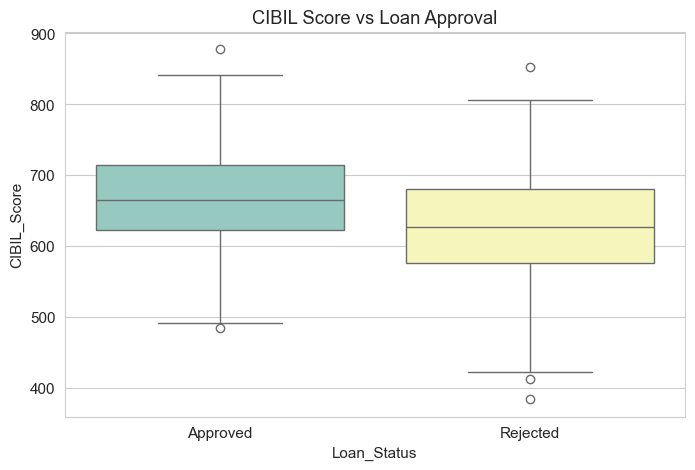

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Loan_Status",
    y="CIBIL_Score",
    palette="Set3"
)

plt.title("CIBIL Score vs Loan Approval")
plt.savefig("../visuals/cibil_vs_status.png", dpi=300)
plt.show()

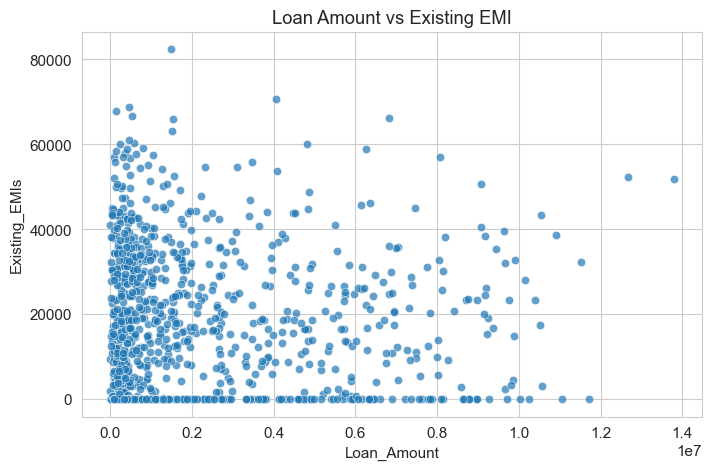

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Loan_Amount",
    y="Existing_EMIs",
    alpha=0.7
)

plt.title("Loan Amount vs Existing EMI")
plt.savefig("../visuals/loan_vs_emi.png", dpi=300)
plt.show()

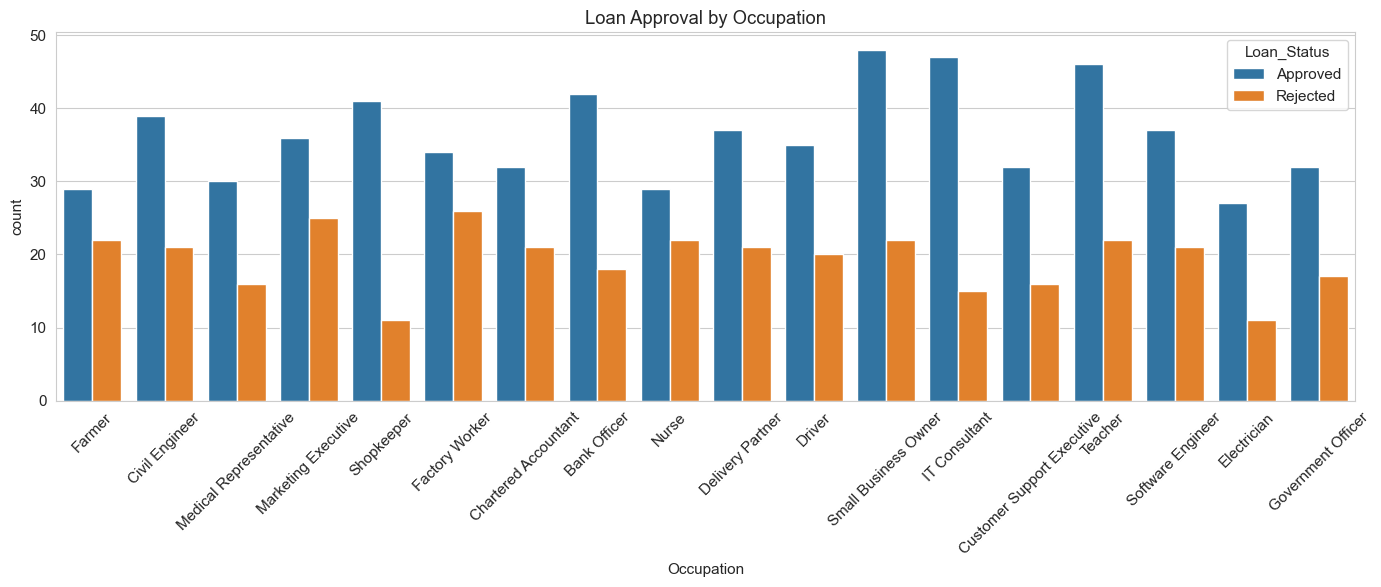

In [26]:
plt.figure(figsize=(14,6))
sns.countplot(
    data=df,
    x="Occupation",
    hue="Loan_Status"
)

plt.xticks(rotation=45)
plt.title("Loan Approval by Occupation")
plt.tight_layout()
plt.savefig("../visuals/occupation_vs_status.png", dpi=300)
plt.show()

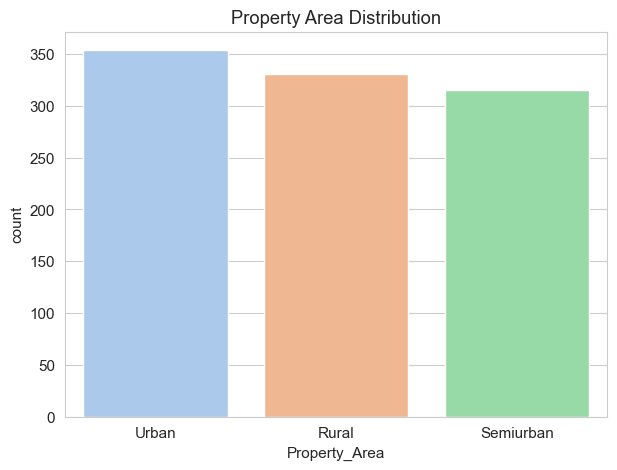

In [27]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Property_Area",
    palette="pastel"
)

plt.title("Property Area Distribution")
plt.savefig("../visuals/property_area.png", dpi=300)
plt.show()

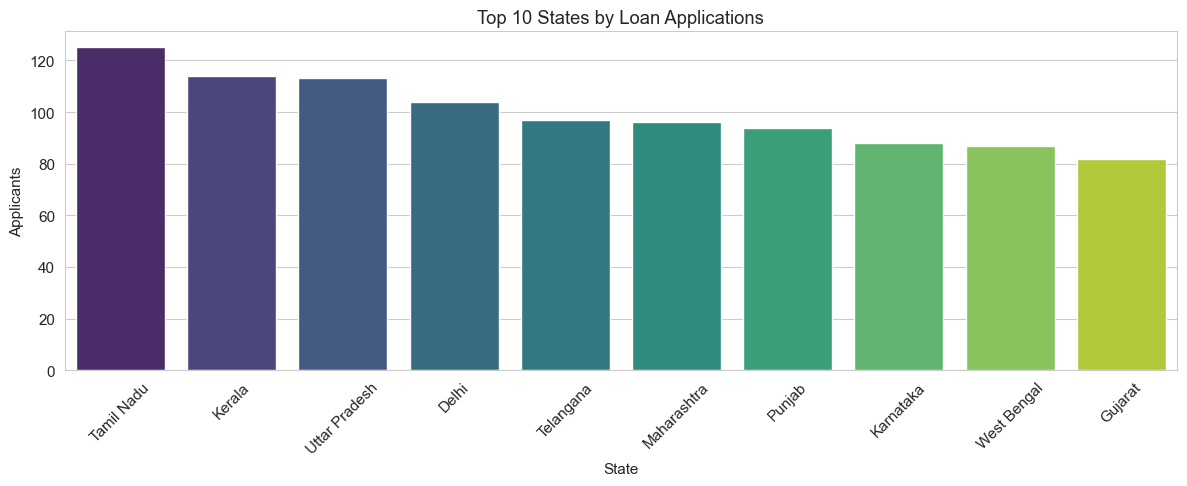

In [29]:
plt.figure(figsize=(12,5))
top_states = df["State"].value_counts().head(10)

sns.barplot(
    x=top_states.index,
    y=top_states.values,
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Top 10 States by Loan Applications")
plt.xlabel("State")
plt.ylabel("Applicants")
plt.tight_layout()
plt.savefig("../visuals/state_wise_applications.png", dpi=300)
plt.show()

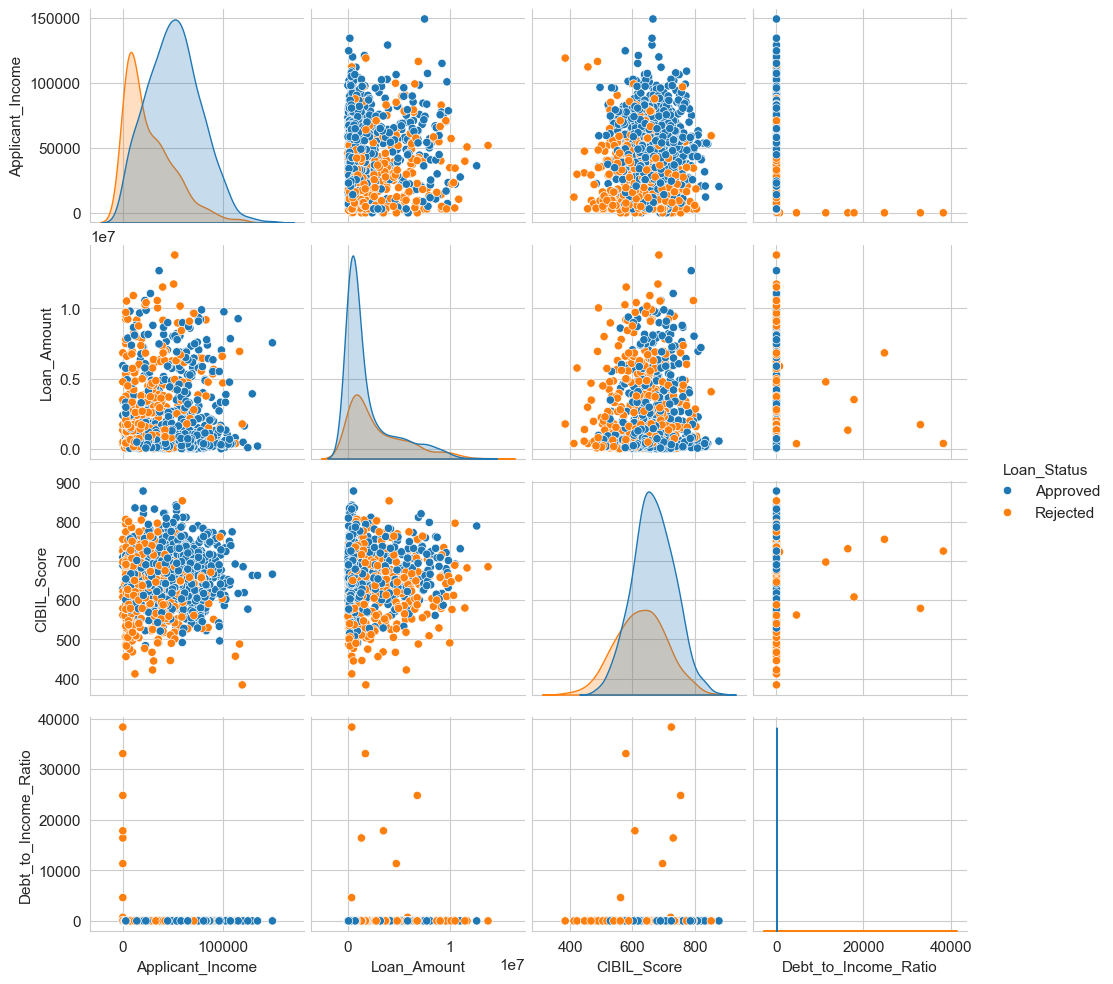

In [30]:
selected_features = [
    "Applicant_Income",
    "Loan_Amount",
    "CIBIL_Score",
    "Debt_to_Income_Ratio",
    "Loan_Status"
]

sns.pairplot(
    df[selected_features],
    hue="Loan_Status"
)

plt.show()

In [31]:
print("="*50)
print("EDA Summary")
print("="*50)

print(f"Total Rows : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

print(f"Numerical Columns : {len(num_cols)}")
print(f"Categorical Columns : {len(cat_cols)}")

print(f"Duplicate Rows : {df.duplicated().sum()}")
print(f"Missing Values : {df.isnull().sum().sum()}")

EDA Summary
Total Rows : 1000
Total Columns : 47
Numerical Columns : 20
Categorical Columns : 27
Duplicate Rows : 0
Missing Values : 1033
